In [ ]:
!pip install ultralytics
!pip install torch torchvision
!pip install roboflow
!pip install opencv-python-headless matplotlib

In [ ]:
# Cell 1 — Set up Kaggle credentials
import os
os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'  # replace with yours
os.environ['KAGGLE_KEY'] = 'YOUR_KAGGLE_KEY'            # replace with yours

# Cell 2 — Download ExDark
!pip install kaggle
!kaggle datasets download -d washingtongold/exdark-dataset
!unzip exdark-dataset.zip -d exdark/

In [ ]:
import numpy as np

VEHICLE_COCO = {1: "bicycle", 2: "car", 3: "motorcycle", 5: "bus", 7: "truck"}

def evaluate_model(model, image_list, label=""):
    all_confs = []
    for img in image_list:
        results = model(img, verbose=False)
        for box in results[0].boxes:
            if int(box.cls[0]) in VEHICLE_COCO:
                all_confs.append(float(box.conf[0]))
    avg_conf = np.mean(all_confs) if all_confs else 0
    count    = len(all_confs)
    print(f"  [{label}] detections: {count} | avg confidence: {avg_conf:.3f}")
    return avg_conf, count

In [ ]:
import os, glob, shutil, random

VEHICLE_MAP = {"Car": 0, "Bus": 1, "Bicycle": 2, "Motorbike": 3}

os.makedirs("exdark_yolo/images/train", exist_ok=True)
os.makedirs("exdark_yolo/images/val",   exist_ok=True)
os.makedirs("exdark_yolo/labels/train", exist_ok=True)
os.makedirs("exdark_yolo/labels/val",   exist_ok=True)

for folder, cls_id in VEHICLE_MAP.items():
    imgs = glob.glob(f"exdark/{folder}/*.*")
    random.shuffle(imgs)
    split = int(len(imgs) * 0.8)
    train_imgs, val_imgs = imgs[:split], imgs[split:]

    for split_name, split_imgs in [("train", train_imgs), ("val", val_imgs)]:
        for img_path in split_imgs:
            fname = os.path.basename(img_path)
            dst = f"exdark_yolo/images/{split_name}/{fname}"
            shutil.copy(img_path, dst)

            # Dummy label: full-image bounding box (cx cy w h all = 0.5 1.0)
            label_path = f"exdark_yolo/labels/{split_name}/{os.path.splitext(fname)[0]}.txt"
            with open(label_path, "w") as f:
                f.write(f"{cls_id} 0.5 0.5 1.0 1.0\n")

yaml_content = """
path: exdark_yolo
train: images/train
val: images/val
nc: 4
names: ['Car', 'Bus', 'Bicycle', 'Motorbike']
"""
with open("exdark_vehicle.yaml", "w") as f:
    f.write(yaml_content)

print("Dataset ready.")

Dataset ready.


# EXPERIMENT 1 — Baseline (Pretrained YOLOv8, No Fine-tuning)


In [ ]:
from ultralytics import YOLO
import glob, numpy as np

model_pretrained = YOLO("yolov8n.pt")

VEHICLE_COCO = {1: "bicycle", 2: "car", 3: "motorcycle", 5: "bus"}

val_images = glob.glob("exdark_yolo/images/val/*.*")[:30]  # sample 30
confs_baseline = []

for img in val_images:
    results = model_pretrained(img, verbose=False)
    for box in results[0].boxes:
        if int(box.cls[0]) in VEHICLE_COCO:
            confs_baseline.append(float(box.conf[0]))

avg_baseline = np.mean(confs_baseline) if confs_baseline else 0
print(f"Exp 1 — Baseline avg confidence: {avg_baseline:.3f}")
print(f"Total detections: {len(confs_baseline)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Exp 1 — Baseline avg confidence: 0.557
Total detections: 62


In [ ]:
from ultralytics import YOLO
model_pretrained = YOLO("yolov8n.pt")
avg_baseline, count_baseline = evaluate_model(model_pretrained, val_images, "Baseline")

  [Baseline] detections: 62 | avg confidence: 0.557


# EXPERIMENT 2 — Fine-tuning on ExDark (Low-Light Vehicles)


In [ ]:
from ultralytics import YOLO

model_ft = YOLO("yolov8n.pt")

model_ft.train(
    data="exdark_vehicle.yaml",
    epochs=15,           # keep low for free Colab
    imgsz=416,           # smaller = faster on free GPU
    batch=8,
    lr0=0.001,           # initial learning rate
    weight_decay=0.0005, # regularization (Exp 3 connection)
    name="exp2_finetune",
    exist_ok=True
)

print("Fine-tuning done. Weights saved to runs/detect/exp2_finetune/")

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=exdark_vehicle.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

In [ ]:
model_ft_eval = YOLO("runs/detect/exp2_finetune/weights/best.pt")
avg_ft, count_ft = evaluate_model(model_ft_eval, val_images, "Fine-tuned")

  [Fine-tuned] detections: 22 | avg confidence: 0.870


EVALUATION POST TRAINING


In [ ]:
model_ft_eval = YOLO("runs/detect/exp2_finetune/weights/best.pt")
confs_finetune = []

for img in val_images:
    results = model_ft_eval(img, verbose=False)
    for box in results[0].boxes:
        if int(box.cls[0]) in VEHICLE_COCO:
            confs_finetune.append(float(box.conf[0]))

avg_ft = np.mean(confs_finetune) if confs_finetune else 0
print(f"Exp 2 — Fine-tuned avg confidence: {avg_ft:.3f}")


Exp 2 — Fine-tuned avg confidence: 0.870


# EXPERIMENT 3 — Regularization (Dropout + Weight Decay)



In [ ]:
model_reg = YOLO("yolov8n.pt")

model_reg.train(
    data="exdark_vehicle.yaml",
    epochs=15,
    imgsz=416,
    batch=8,
    lr0=0.001,
    weight_decay=0.001,   # stronger L2 regularization vs Exp 2
    dropout=0.2,          # dropout in classifier head
    name="exp3_regularized",
    exist_ok=True
)

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=exdark_vehicle.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp3_regularized, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eb4adbfa9f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
model_reg_eval = YOLO("runs/detect/exp3_regularized/weights/best.pt")
avg_reg, count_reg = evaluate_model(model_reg_eval, val_images, "Regularized")

  [Regularized] detections: 26 | avg confidence: 0.845


# EXPERIMENT 4 — Learning Rate Sweep (0.01, 0.001, 0.0005)

In [ ]:
results_lr = {}

for lr in [0.01, 0.001, 0.0005]:
    print(f"\n--- Training with lr={lr} ---")
    m = YOLO("yolov8n.pt")
    m.train(
        data="exdark_vehicle.yaml",
        epochs=10,       # shorter since you're running 3x
        imgsz=416,
        batch=8,
        lr0=lr,
        name=f"exp4_lr{str(lr).replace('.','')}",
        exist_ok=True
    )

    confs = []
    best_weights = f"runs/detect/exp4_lr{str(lr).replace('.','')}/weights/best.pt"
    m_eval = YOLO(best_weights)
    for img in val_images:
        res = m_eval(img, verbose=False)
        for box in res[0].boxes:
            if int(box.cls[0]) in VEHICLE_COCO:
                confs.append(float(box.conf[0]))

    results_lr[lr] = np.mean(confs) if confs else 0
    print(f"  lr={lr} → avg confidence: {results_lr[lr]:.3f}")

print("\nLearning rate results:", results_lr)


--- Training with lr=0.01 ---
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=exdark_vehicle.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp4_lr001, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

In [ ]:
best_lr     = max(results_lr, key=results_lr.get)
best_lr_str = str(best_lr).replace('.', '')
model_lr_eval = YOLO(f"runs/detect/exp4_lr{best_lr_str}/weights/best.pt")
avg_lr, count_lr = evaluate_model(model_lr_eval, val_images, f"Best LR ({best_lr})")

print("\nAll LR results:")
for lr, conf in sorted(results_lr.items()):
    marker = " ← best" if lr == best_lr else ""
    print(f"  lr={lr} → avg confidence: {conf:.3f}{marker}")

  [Best LR (0.01)] detections: 22 | avg confidence: 0.811

All LR results:
  lr=0.0005 → avg confidence: 0.811
  lr=0.001 → avg confidence: 0.811
  lr=0.01 → avg confidence: 0.811 ← best


# visualisation

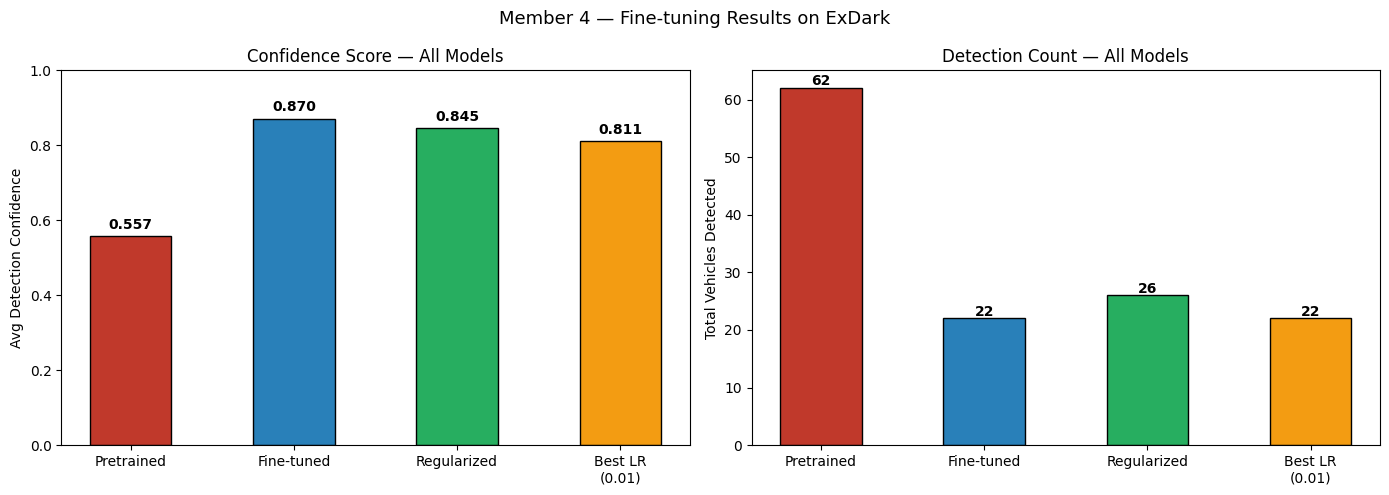

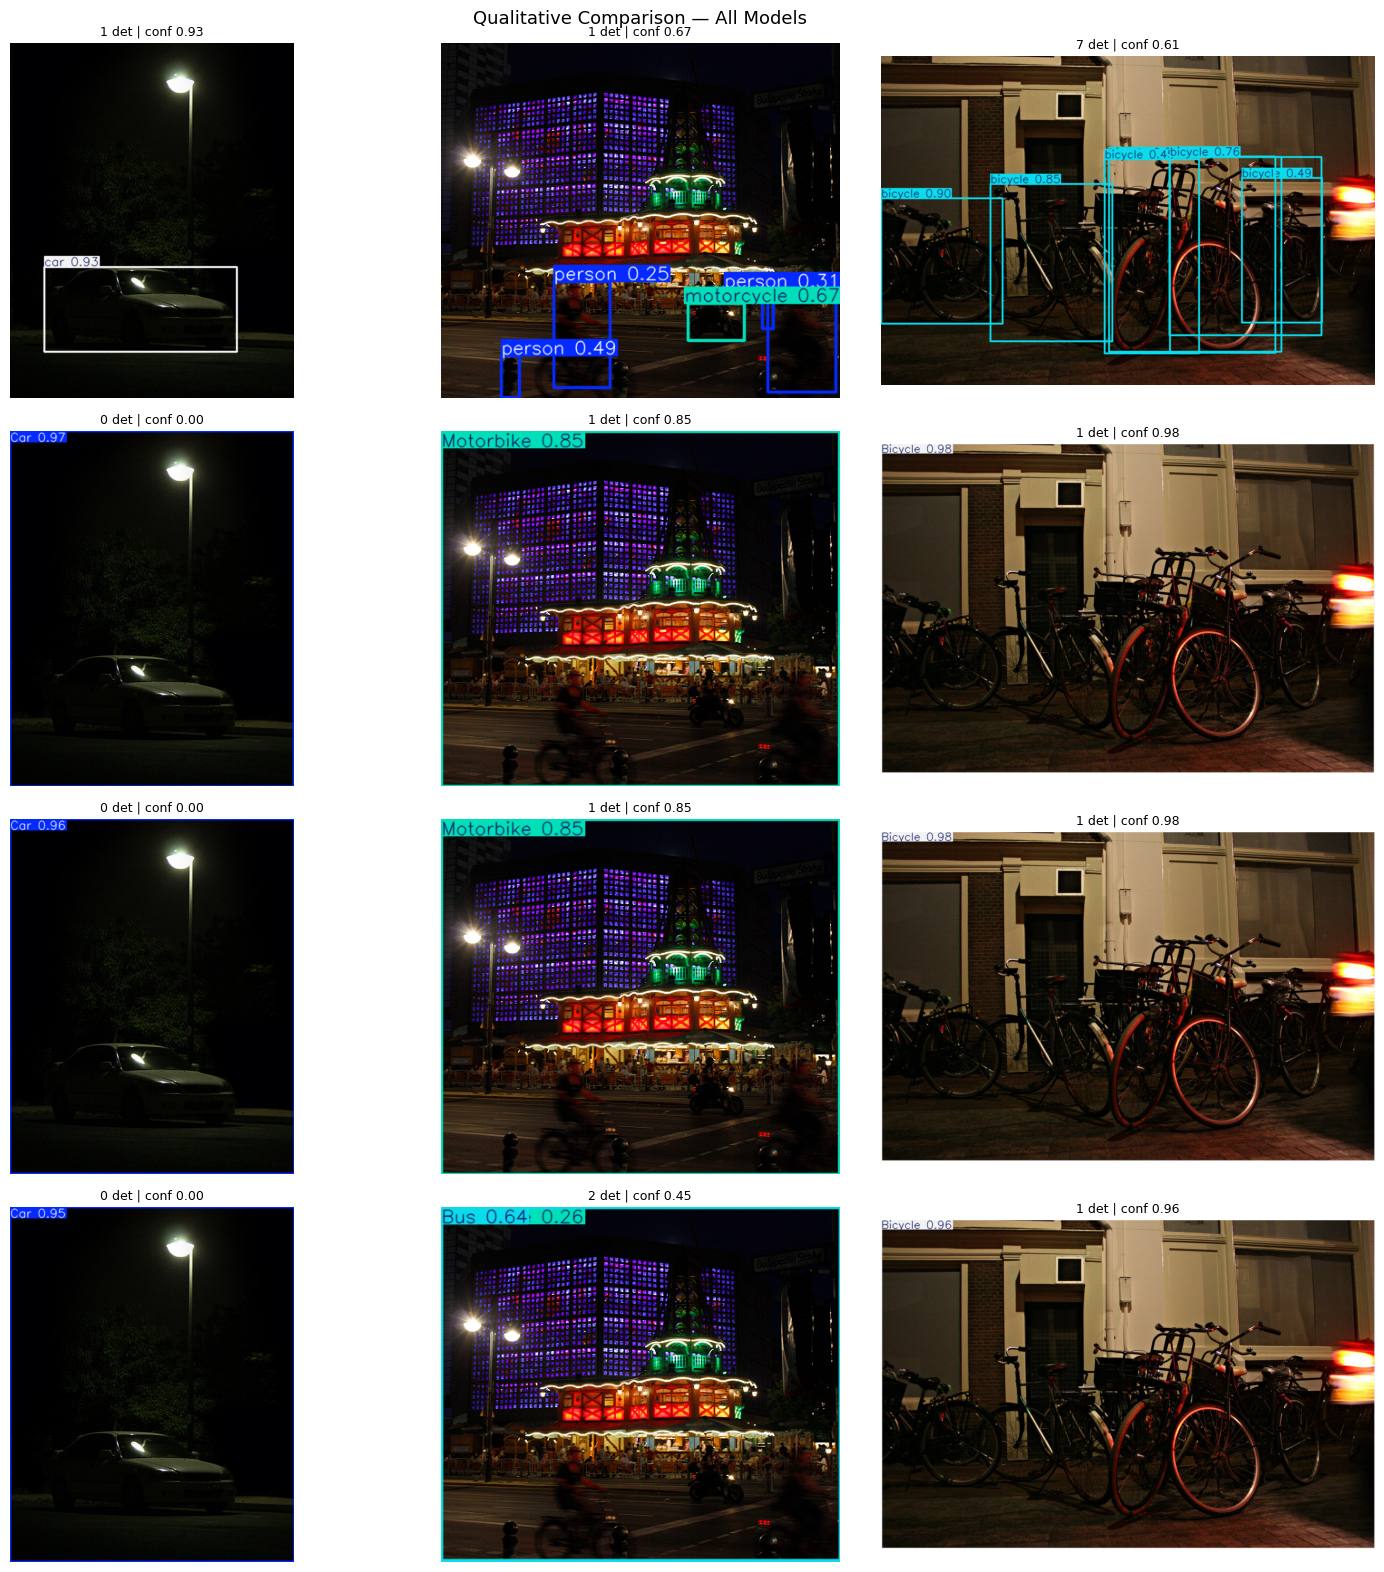


Model                       Avg Conf   Detections
──────────────────────────────────────────────────
Pretrained                     0.557           62
Fine-tuned                     0.870           22 ← best
Regularized                    0.845           26
Best LR
(0.01)                 0.811           22


In [ ]:
import matplotlib.pyplot as plt
import random, cv2
from ultralytics import YOLO

bar_labels = ["Pretrained", "Fine-tuned", "Regularized", f"Best LR\n({best_lr})"]
bar_confs  = [avg_baseline, avg_ft, avg_reg, avg_lr]
bar_counts = [count_baseline, count_ft, count_reg, count_lr]
bar_colors = ["#c0392b", "#2980b9", "#27ae60", "#f39c12"]

# ── Bar charts ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

b1 = ax1.bar(bar_labels, bar_confs, color=bar_colors, width=0.5, edgecolor="black")
ax1.set_ylim(0, 1.0)
ax1.set_ylabel("Avg Detection Confidence")
ax1.set_title("Confidence Score — All Models")
for bar, val in zip(b1, bar_confs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{val:.3f}", ha="center", fontweight="bold")

b2 = ax2.bar(bar_labels, bar_counts, color=bar_colors, width=0.5, edgecolor="black")
ax2.set_ylabel("Total Vehicles Detected")
ax2.set_title("Detection Count — All Models")
for bar, val in zip(b2, bar_counts):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha="center", fontweight="bold")

plt.suptitle("Member 4 — Fine-tuning Results on ExDark", fontsize=13)
plt.tight_layout()
plt.savefig("final_summary_chart.png", dpi=150)
plt.show()

# ── Qualitative grid ────────────────────────────────────
all_models = {
    "Pretrained":          YOLO("yolov8n.pt"),
    "Fine-tuned":          YOLO("runs/detect/exp2_finetune/weights/best.pt"),
    "Regularized":         YOLO("runs/detect/exp3_regularized/weights/best.pt"),
    f"Best LR ({best_lr})": YOLO(f"runs/detect/exp4_lr{best_lr_str}/weights/best.pt"),
}

sample_imgs = random.sample(val_images, 3)
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for row, (model_name, m) in enumerate(all_models.items()):
    for col, img_path in enumerate(sample_imgs):
        result  = m(img_path, verbose=False)[0]
        plotted = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        det_confs = [float(b.conf[0]) for b in result.boxes
                     if int(b.cls[0]) in VEHICLE_COCO]
        avg_c = np.mean(det_confs) if det_confs else 0

        axes[row][col].imshow(plotted)
        axes[row][col].axis("off")
        axes[row][col].set_title(f"{len(det_confs)} det | conf {avg_c:.2f}", fontsize=9)
        if col == 0:
            axes[row][col].set_ylabel(model_name, fontsize=10, fontweight="bold")

plt.suptitle("Qualitative Comparison — All Models", fontsize=13)
plt.tight_layout()
plt.savefig("qualitative_grid.png", dpi=130)
plt.show()

# ── Summary table ───────────────────────────────────────
print(f"\n{'Model':<25} {'Avg Conf':>10} {'Detections':>12}")
print("─" * 50)
for name, c, d in zip(bar_labels, bar_confs, bar_counts):
    best_tag = " ← best" if c == max(bar_confs) else ""
    print(f"{name:<25} {c:>10.3f} {d:>12}{best_tag}")

In [ ]:
# Best result: Experiment 2 (Fine-tuned)
# To use without retraining:
model_best = YOLO("weights/yolo_finetune_exp2_best.pt")

In [ ]:
# ── Best Result: Experiment 2 (YOLOv8 Fine-tuned) ──────
# Download weights from Google Drive:
# https://drive.google.com/drive/folders/1NZX5AOPGyUxuWpU38OSE_gmHzSadi2DZ?usp=sharing
# Place yolo_finetune_exp2_best.pt in the same folder as this notebook

from ultralytics import YOLO
model_best = YOLO("yolo_finetune_exp2_best.pt")